In [2]:
import pandas as pd

df = pd.read_csv("Car details v3.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [3]:
df.shape

(8128, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [5]:
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

In [6]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque',
       'seats'],
      dtype='object')

In [8]:
df.drop(['name'], axis=1, inplace=True, errors='ignore')

In [10]:
df['car_age'] = 2026 - df['year']
df.drop(['year'], axis=1, inplace=True, errors='ignore')

In [11]:
df['mileage'] = df['mileage'].str.extract(r'(\d+\.?\d*)').astype(float)
df['engine'] = df['engine'].str.extract(r'(\d+\.?\d*)').astype(float)
df['max_power'] = df['max_power'].str.extract(r'(\d+\.?\d*)').astype(float)

In [13]:
df.head()

,selling_price,km_driven,mileage,engine,max_power,seats,car_age,fuel_Diesel,fuel_LPG,fuel_Petrol,...,torque_96.1Nm@ 3000rpm,torque_96Nm@ 2500rpm,torque_96Nm@ 3000rpm,torque_96Nm@ 3500rpm,torque_98Nm@ 1600-3000rpm,torque_99.04Nm@ 4500rpm,torque_99.07Nm@ 4500rpm,torque_99.1Nm@ 4500rpm,torque_99.8Nm@ 2700rpm,torque_99Nm@ 4500rpm
0,450000,145500,23.40,1248.0,74.00,5.0,12,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,370000,120000,21.14,1498.0,103.52,5.0,12,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,158000,140000,17.70,1497.0,78.00,5.0,20,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,225000,127000,23.00,1396.0,90.00,5.0,16,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,130000,120000,16.10,1298.0,88.20,5.0,19,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [16]:
df = pd.get_dummies(df, drop_first=True)

In [17]:
X = df.drop('selling_price', axis=1)
y = df['selling_price']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
X.head()

,km_driven,mileage,engine,max_power,seats,car_age,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,...,torque_96.1Nm@ 3000rpm,torque_96Nm@ 2500rpm,torque_96Nm@ 3000rpm,torque_96Nm@ 3500rpm,torque_98Nm@ 1600-3000rpm,torque_99.04Nm@ 4500rpm,torque_99.07Nm@ 4500rpm,torque_99.1Nm@ 4500rpm,torque_99.8Nm@ 2700rpm,torque_99Nm@ 4500rpm
0,145500,23.40,1248.0,74.00,5.0,12,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,120000,21.14,1498.0,103.52,5.0,12,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,140000,17.70,1497.0,78.00,5.0,20,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
3,127000,23.00,1396.0,90.00,5.0,16,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,120000,16.10,1298.0,88.20,5.0,19,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False


In [20]:
y.head()

0    450000
1    370000
2    158000
3    225000
4    130000
Name: selling_price, dtype: int64

In [21]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
y_pred = model.predict(X_test)

In [23]:
from sklearn.metrics import r2_score

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.9703888224165398


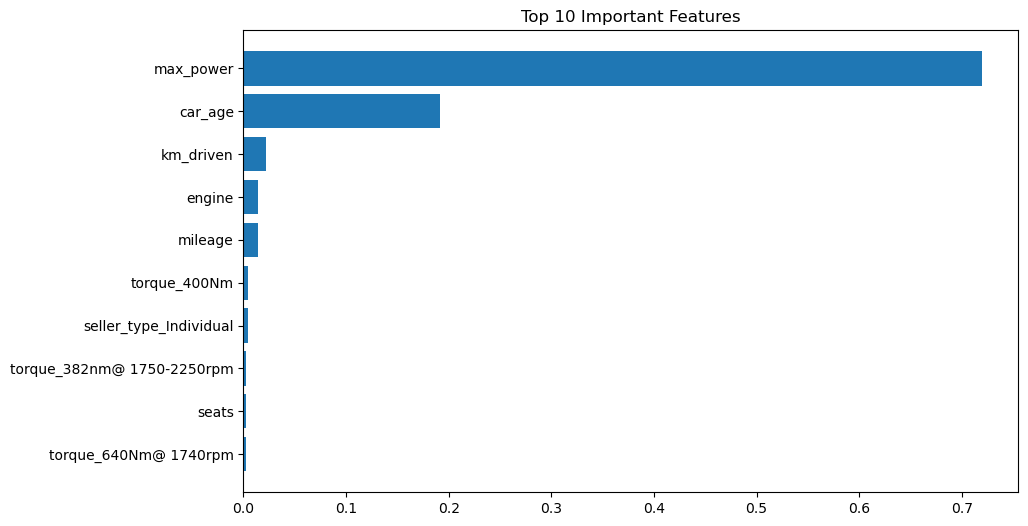

In [26]:
import numpy as np
import matplotlib.pyplot as plt

importances = model.feature_importances_

indices = np.argsort(importances)[-10:]  # top 10

plt.figure(figsize=(10,6))
plt.barh(X.columns[indices], importances[indices])
plt.title("Top 10 Important Features")
plt.show()

In [27]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
y_pred = model.predict(X_test)
print(r2_score(y_test, y_pred))

0.9679586333754898


In [29]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)
model.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)
model.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
model = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_split=3,
    min_samples_leaf=2,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,12
,min_samples_split,3
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
y_pred = model.predict(X_test)

from sklearn.metrics import r2_score

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.9680426723483152


In [33]:
!pip install xgboost

In [36]:
df.dropna(inplace=True)

In [37]:
df.isnull().sum()

selling_price              0
km_driven                  0
mileage                    0
engine                     0
max_power                  0
                          ..
torque_99.04Nm@ 4500rpm    0
torque_99.07Nm@ 4500rpm    0
torque_99.1Nm@ 4500rpm     0
torque_99.8Nm@ 2700rpm     0
torque_99Nm@ 4500rpm       0
Length: 457, dtype: int64

In [38]:
X = df.drop('selling_price', axis=1)
y = df['selling_price']

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [40]:
X_train.isnull().sum()
X_test.isnull().sum()

km_driven                  0
mileage                    0
engine                     0
max_power                  0
seats                      0
                          ..
torque_99.04Nm@ 4500rpm    0
torque_99.07Nm@ 4500rpm    0
torque_99.1Nm@ 4500rpm     0
torque_99.8Nm@ 2700rpm     0
torque_99Nm@ 4500rpm       0
Length: 456, dtype: int64

In [42]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [43]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
lr_pred = lr.predict(X_test)

In [45]:
print(X_train.shape)
print(X_test.shape)
print(X_train.isnull().sum().sum())

(6324, 456)
(1582, 456)
0


In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("Linear Regression")
print("R2:", r2_score(y_test, lr_pred))
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))

Linear Regression
R2: 0.8143077525442917
MAE: 138682.45085142777
RMSE: 359316.9498044771


In [47]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [48]:
rf_pred = rf_model.predict(X_test)

In [49]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("Random Forest")
print("R2:", r2_score(y_test, rf_pred))
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))

Random Forest
R2: 0.9816290564578987
MAE: 69220.17541866095
RMSE: 113017.72198928792


In [51]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor()

In [52]:
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [53]:
xgb_pred = xgb_model.predict(X_test)

In [54]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("XGBoost")
print("R2:", r2_score(y_test, xgb_pred))
print("MAE:", mean_absolute_error(y_test, xgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))

XGBoost
R2: 0.9837996959686279
MAE: 66273.4375
RMSE: 106130.98985687451


In [55]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "R2": [r2_score(y_test, lr_pred),
           r2_score(y_test, rf_pred),
           r2_score(y_test, xgb_pred)]
})

results

,Model,R2
0,Linear Regression,0.814308
1,Random Forest,0.981629
2,XGBoost,0.983800


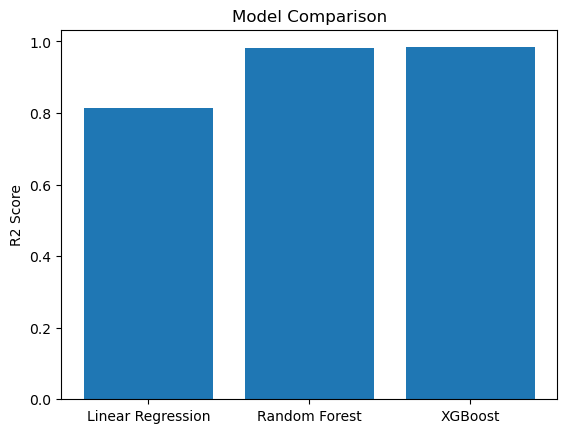

In [56]:
import matplotlib.pyplot as plt

plt.bar(results["Model"], results["R2"])
plt.ylabel("R2 Score")
plt.title("Model Comparison")
plt.show()

In [57]:
import joblib

joblib.dump(xgb_model, "car_price_model.pkl")

['car_price_model.pkl']

In [58]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [59]:
from sklearn.metrics import r2_score

lr_score = r2_score(y_test, lr_pred)
print("Linear Regression R2:", lr_score)

Linear Regression R2: 0.8143077525442917


In [60]:
rf_score = r2_score(y_test, rf_pred)

In [62]:
xgb_score = r2_score(y_test, xgb_pred)

In [63]:
results = {
    "Linear Regression": lr_score,
    "Random Forest": rf_score,
    "XGBoost": xgb_score
}

best_model = max(results, key=results.get)

print(results)
print("Best Model:", best_model)

{'Linear Regression': 0.8143077525442917, 'Random Forest': 0.9816290564578987, 'XGBoost': 0.9837996959686279}
Best Model: XGBoost


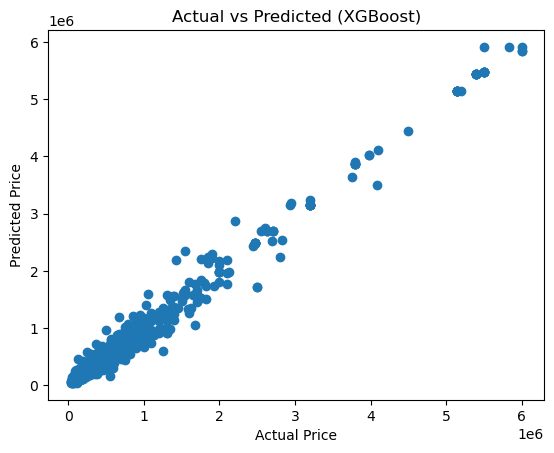

In [65]:
plt.scatter(y_test, xgb_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (XGBoost)")
plt.show()

In [66]:
import joblib

joblib.dump(xgb_model, "car_price_model.pkl")


['car_price_model.pkl']

In [67]:
sample = X_test.iloc[0].values.reshape(1, -1)

print("Predicted:", xgb_model.predict(sample))
print("Actual:", y_test.iloc[0])

Predicted: [462150.8]
Actual: 501000


In [70]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(xgb_model, X, y, cv=5, scoring='r2')
print("CV R2 Mean:", scores.mean())

CV R2 Mean: 0.9611295342445374


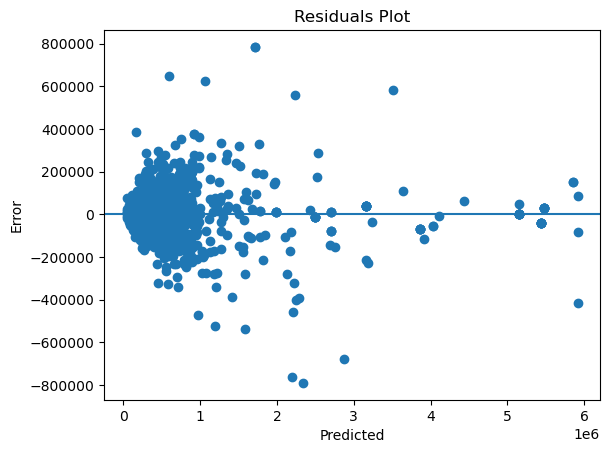

In [72]:
residuals = y_test - xgb_pred

plt.scatter(xgb_pred, residuals)
plt.axhline(y=0)
plt.title("Residuals Plot")
plt.xlabel("Predicted")
plt.ylabel("Error")
plt.show()

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr[['selling_price']].sort_values(by='selling_price', ascending=False),
            cmap='coolwarm')

plt.show()

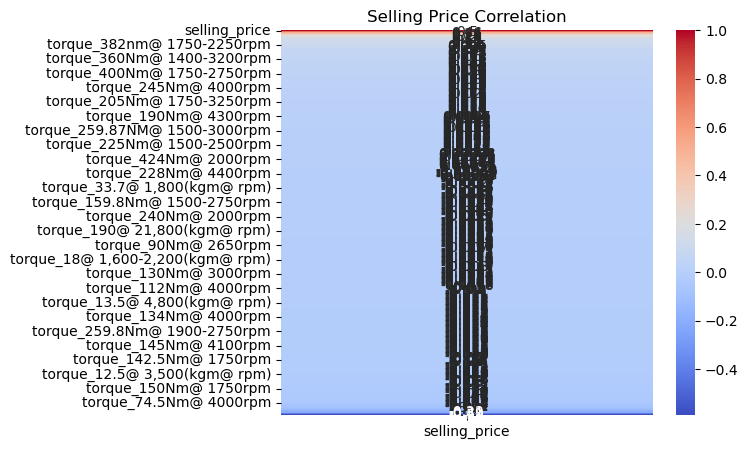

In [78]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(6,5))

sns.heatmap(
    corr[['selling_price']].sort_values(by='selling_price', ascending=False),
    cmap='coolwarm',
    annot=True
)

plt.title("Selling Price Correlation")
plt.show()